In [1]:
import os
import pickle
import tarfile
import datetime
import numpy as np
import urllib.request
import sklearn.metrics
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from pathlib import Path

In [2]:
rng = np.random.default_rng()

In [3]:
def get_data():
    if not os.path.exists('cifar-10-batches-py/'):
        urllib.request.urlretrieve('https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz', 'cifar-10-python.tar.gz')
        file = tarfile.open('cifar-10-python.tar.gz', 'r:gz')
        file.extractall()

    X, y = [], []
    for i in range(1, 6):
        d = pickle.load(open(os.path.join('cifar-10-batches-py', f'data_batch_{i}'), 'rb'), encoding='bytes')
        X.append(d[b'data'])
        y.append(d[b'labels'])

    d = pickle.load(open(os.path.join('cifar-10-batches-py', 'test_batch'), 'rb'), encoding='bytes')

    return (
        np.concatenate(X, axis=0).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1),
        np.concatenate(y, axis=0),
        pickle.load(open('cifar-10-batches-py/batches.meta', 'rb'))['label_names'],
        np.array(d[b'data']).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1),
        np.array(d[b'labels'])
    )

In [4]:
def plot_confusion_matrix(model: tf.keras.models.Model, X: np.ndarray, y: np.ndarray, labels: list[str], batch_size: int = 8, **kwargs):
    sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
        y,
        model.predict(X, verbose=False, batch_size=batch_size)[output_index].argmax(axis=-1),
        display_labels=labels,
        xticks_rotation='vertical',
        **kwargs
    )

In [5]:
def plot_grid_and_label(X, y, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, label_description=None, gray=False):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]

    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])

    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            if gray:
                ax[i, j].imshow(imgs[i, j], cmap="gray")
            else:
                ax[i, j].imshow(imgs[i, j])
            ax[i, j].set_title(map_label(labels[i, j]))
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

def plot_grid_and_label_(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=False, label_description=None, gray=False):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])

    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)

    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])

    preds = np.argmax(tf.nn.softmax(model.predict(inputs)), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            if gray:
                ax[i, j].imshow(imgs[i, j], cmap='gray')
            else:
                ax[i, j].imshow(imgs[i, j])
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [6]:
X, y, labels, X_test, y_test = get_data()

In [7]:
labels

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

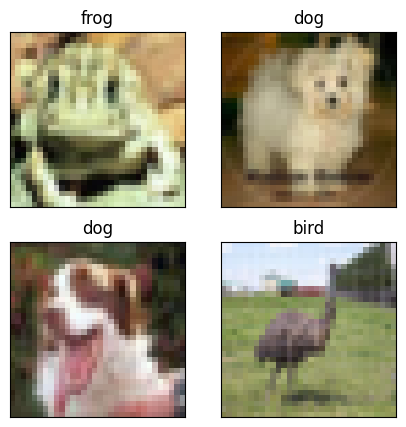

In [8]:
plot_grid_and_label(X, y, label_description=labels, figsize=(5, 5))

In [9]:
# CNN model

cntr = 1
cntr1 = 1


def conv_block(x_: keras.KerasTensor, features: int, max_pool: bool = False):
    global cntr1
    x_ = keras.layers.Conv2D(features, 3, padding="same", name=f"conv_{cntr1}")(x_)
    x_ = keras.layers.BatchNormalization(name=f"bn_{cntr1}")(x_)
    x_ = keras.layers.Activation("relu", name=f"activ_{cntr1}")(x_)
    if max_pool:
        x_ = keras.layers.MaxPool2D(name=f"pool_{cntr1}")(x_)
    cntr1 += 1
    return x_


def resnet_block(x_: keras.KerasTensor, features: int):
    global cntr
    if x_.shape[-1] != features:
        y_ = keras.layers.Conv2D(features, 1, name=f"b{cntr}_proj")(x_)
    else:
        y_ = x_

    x_ = keras.layers.Conv2D(features, 3, padding="same", name=f"b{cntr}_conv1")(x_)
    x_ = keras.layers.BatchNormalization(name=f"b{cntr}_bn_1")(x_)
    x_ = keras.layers.Activation("relu", name=f"b{cntr}_activ1")(x_)
    x_ = keras.layers.Conv2D(features, 3, padding="same", name=f"b{cntr}_conv2")(x_)
    x_ = keras.layers.Add(name=f"b{cntr}_add")([x_, y_])
    x_ = keras.layers.BatchNormalization(name=f"b{cntr}_bn_2")(x_)
    x_ = keras.layers.Activation("relu", name=f"b{cntr}_activ2")(x_)
    cntr += 1
    return x_


inputs_ = x_ = keras.layers.Input(shape=(32, 32, 3), dtype="float32", name="inputs")

x_ = conv_block(x_, 64)
x_ = conv_block(x_, 128, max_pool=True)
x_ = keras.layers.Dropout(0.3, name="drop_1")(x_)

x_ = resnet_block(x_, 128)
x_ = keras.layers.Dropout(0.3, name="drop_2")(x_)

x_ = conv_block(x_, 256, max_pool=True)
x_ = conv_block(x_, 512, max_pool=True)
x_ = keras.layers.Dropout(0.3, name="drop_3")(x_)

x_ = keras.layers.Conv2D(1024, 3, padding="same", name="wide")(x_)

x_ = resnet_block(x_, 512)
x_ = keras.layers.Dropout(0.3, name="drop_4")(x_)

x_ = keras.layers.GlobalMaxPooling2D(name="G_avg_pool")(x_)

x_ = keras.layers.Dense(10, activation="softmax", name="Output")(x_)

model = keras.models.Model(inputs=inputs_, outputs=x_, name="M_conv_cifar")

In [10]:
model.summary()

Model: "M_conv_cifar"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 32, 32,    │      1,792 │ inputs[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 32, 32,    │        256 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activ_1             │ (None, 32, 32,    │          0 │ bn_1[0][0]        │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, 32, 32,    │     73,856 │ activ_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 32, 32,    │        512 │ conv_2[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activ_2             │ (None, 32, 32,    │          0 │ bn_2[0][0]        │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 16, 16,    │          0 │ activ_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 16, 16,    │          0 │ pool_2[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_conv1 (Conv2D)   │ (None, 16, 16,    │    147,584 │ drop_1[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_bn_1             │ (None, 16, 16,    │        512 │ b1_conv1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_activ1           │ (None, 16, 16,    │          0 │ b1_bn_1[0][0]     │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_conv2 (Conv2D)   │ (None, 16, 16,    │    147,584 │ b1_activ1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_add (Add)        │ (None, 16, 16,    │          0 │ b1_conv2[0][0],   │
│                     │ 128)              │            │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_bn_2             │ (None, 16, 16,    │        512 │ b1_add[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ b1_activ2           │ (None, 16, 16,    │          0 │ b1_bn_2[0][0]     │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 16, 16,    │          0 │ b1_activ2[0][0]   │
│                     │ 128)              │            │                 

 Total params: 14,183,562 (54.11 MB)

 Trainable params: 14,179,082 (54.09 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [11]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [12]:
model.fit(X, y, epochs=100, callbacks=[
        keras.callbacks.ModelCheckpoint(str(Path("cifar-10") / "models" / "model_cifar.keras"), save_best_only=True, monitor='val_loss', mode="min"),
        keras.callbacks.ReduceLROnPlateau("val_loss", factor=0.5, patience=5, mode="min", min_delta=0.001, min_lr=0.00001),
    ],
    validation_data=(X_test, y_test), batch_size=256)

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 88s 279ms/step - accuracy: 0.3852 - loss: 1.9652 - val_accuracy: 0.3957 - val_loss: 1.7188 - learning_rate: 0.0010
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 93s 168ms/step - accuracy: 0.6633 - loss: 0.9554 - val_accuracy: 0.5819 - val_loss: 1.1664 - learning_rate: 0.0010
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.7456 - loss: 0.7334 - val_accuracy: 0.6407 - val_loss: 1.1040 - learning_rate: 0.0010
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - accuracy: 0.7828 - loss: 0.6182 - val_accuracy: 0.6361 - val_loss: 1.1276 - learning_rate: 0.0010
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 175ms/step - accuracy: 0.8157 - loss: 0.5305 - val_accuracy: 0.8035 - val_loss: 0.5899 - learning_rate: 0.0010
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 170ms/step - accuracy: 0.8395 - loss: 0.4633 - val_accuracy: 0.7329 - val_loss: 0.7831 - learning_rate: 0.0010
Epoch 7/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - accura

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


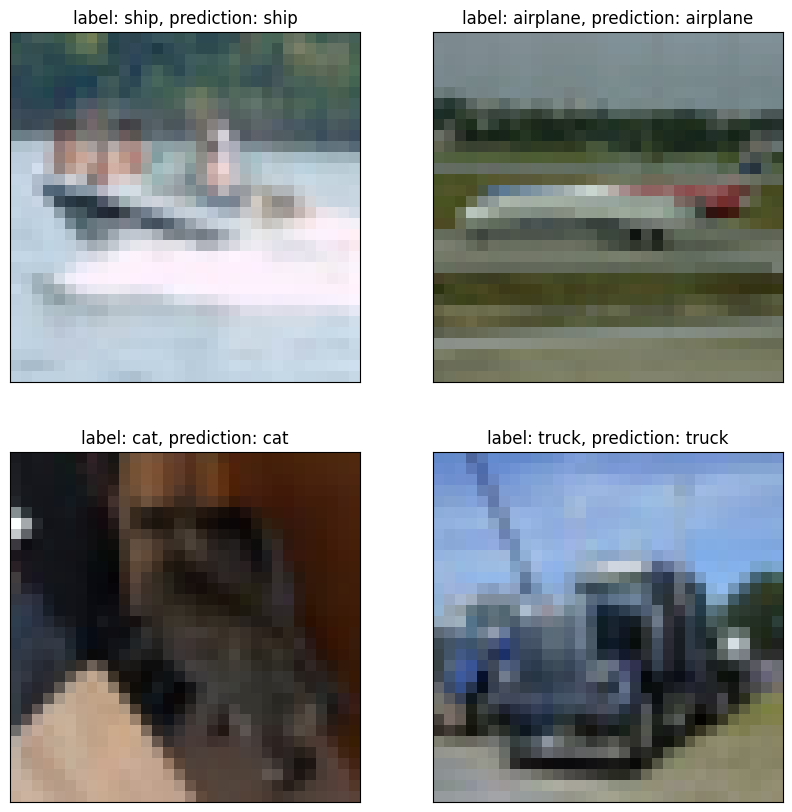

In [13]:
plot_grid_and_label_(X_test, y_test, model, label_description=labels)

In [14]:
y_pred = model.predict(X_test, batch_size=64)
y_pred = np.argmax(y_pred, axis=-1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step


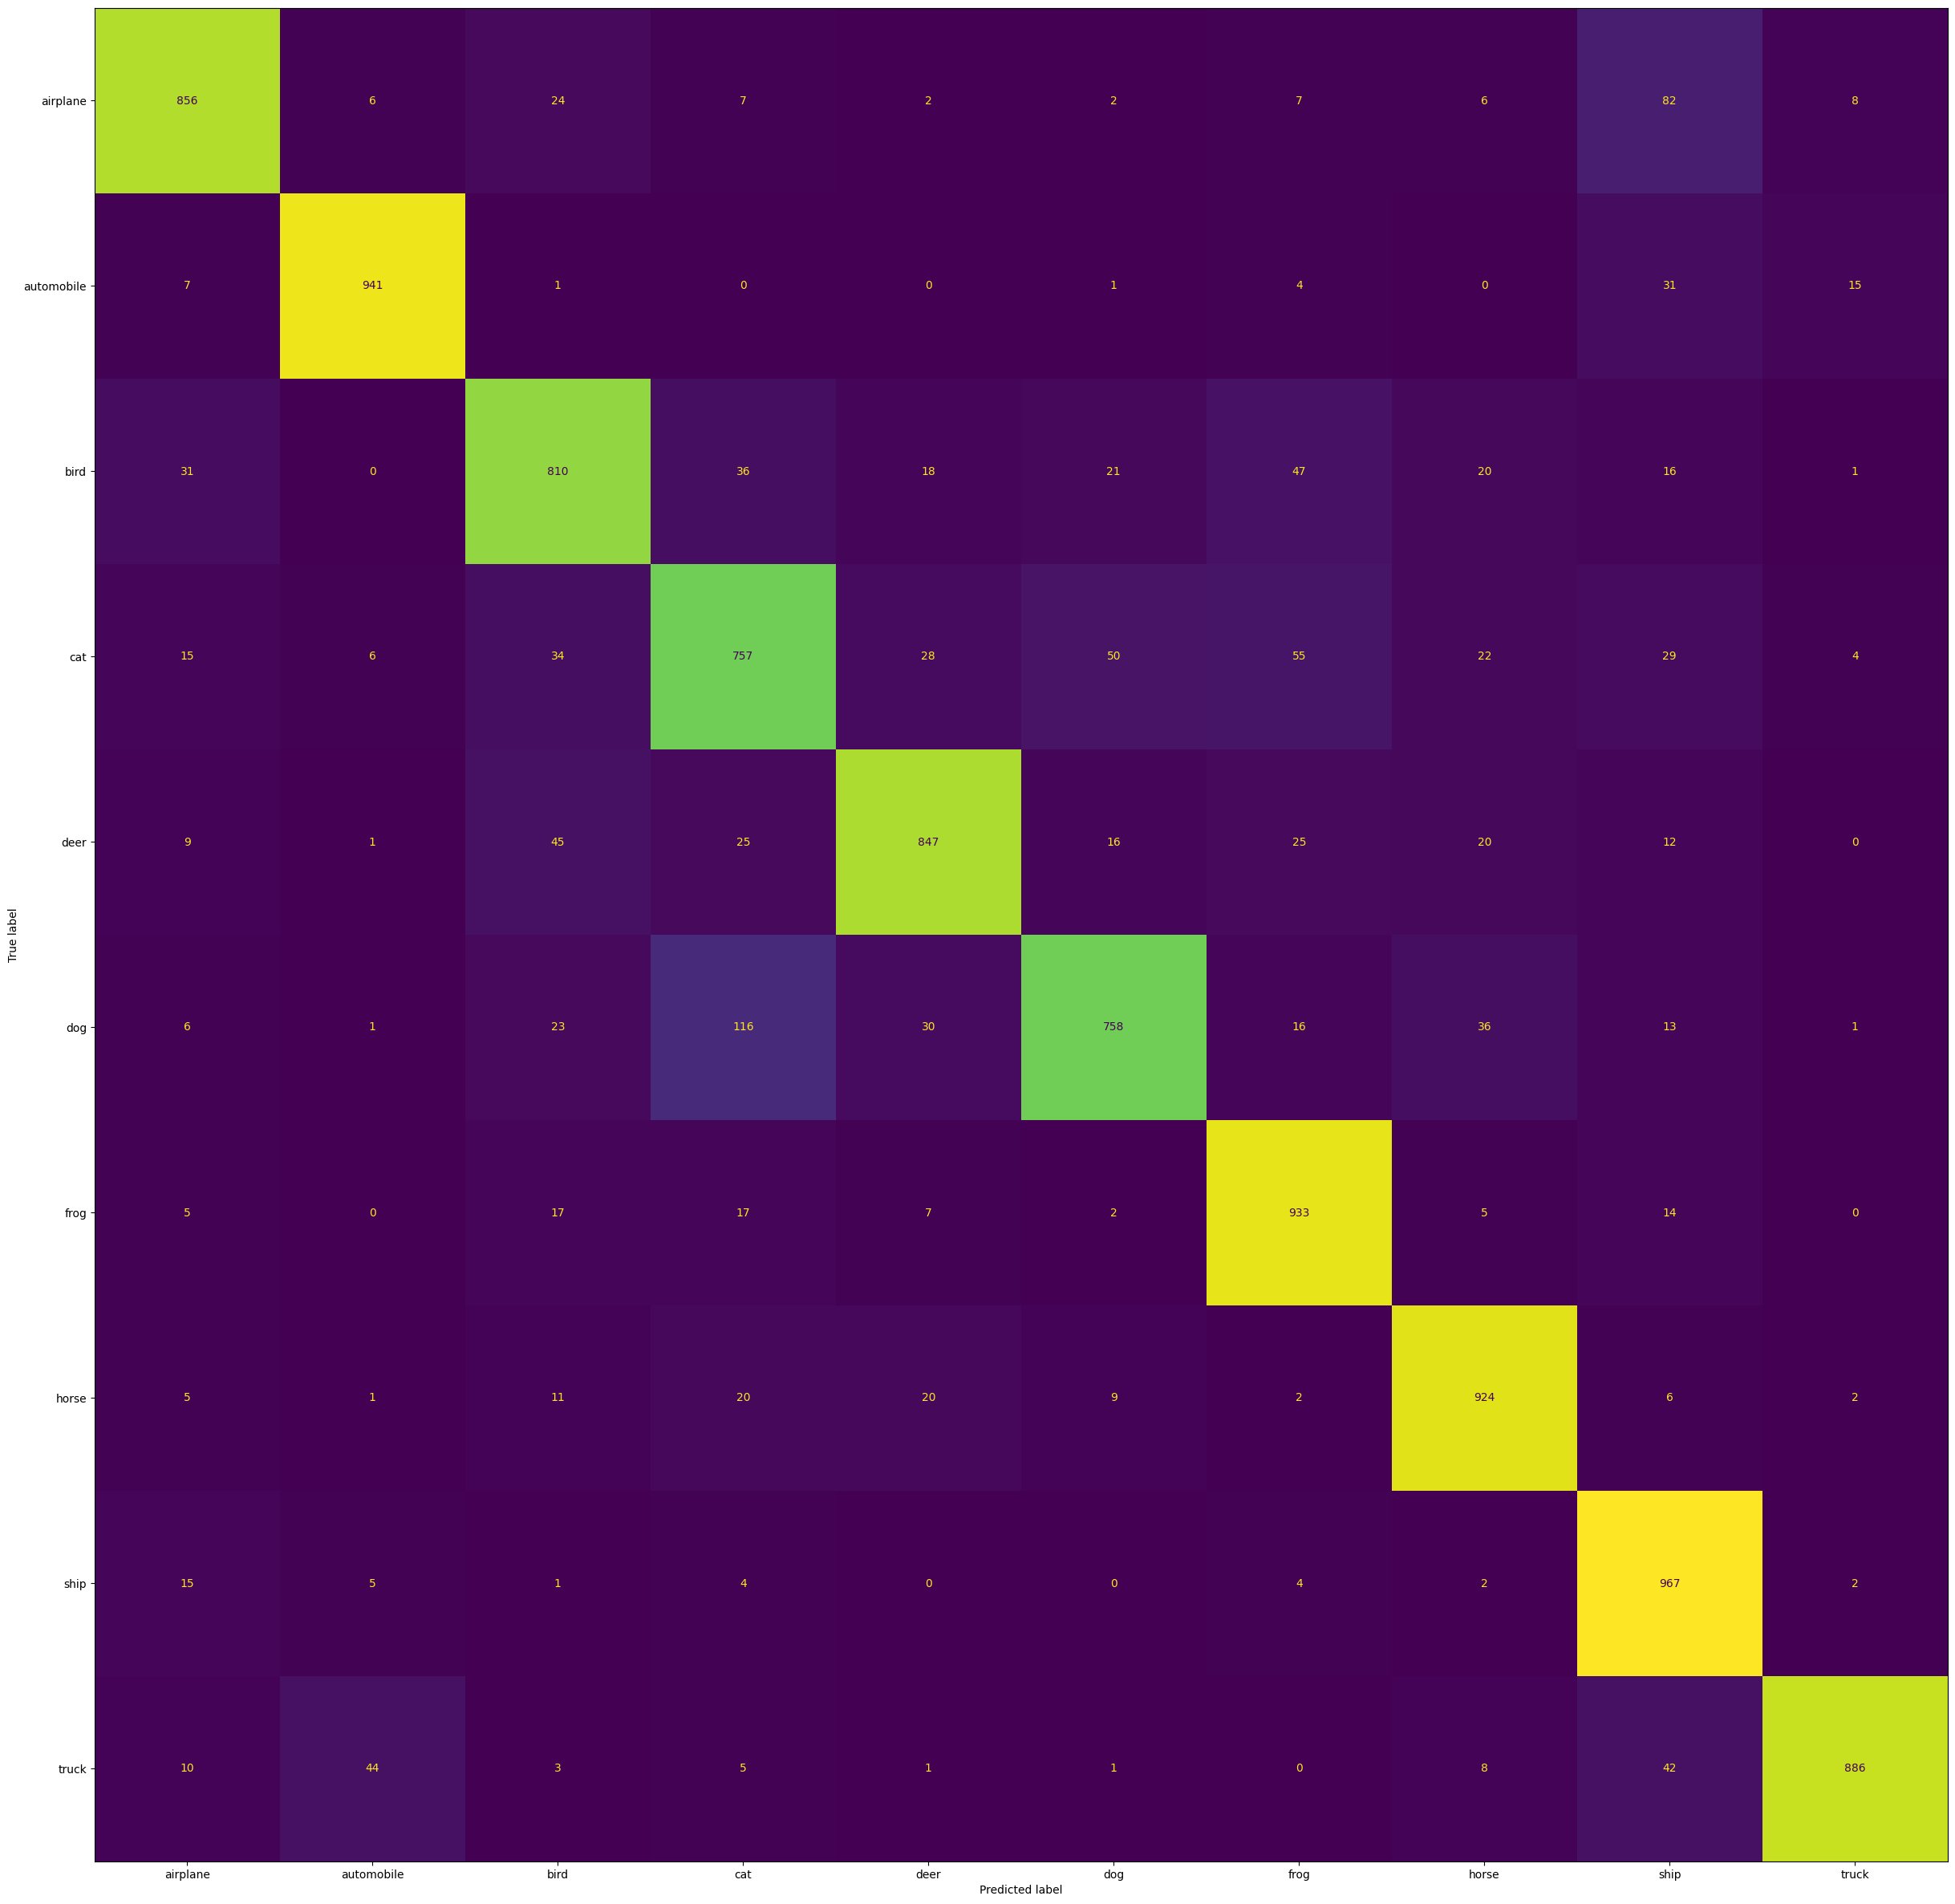

In [15]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=labels, ax=ax, colorbar=False)

In [16]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(10)])

np.float64(0.8679)